In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import preprocessing modules from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Set visualization style
sns.set_theme(style="darkgrid")
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the dataset
df = pd.read_csv('IBM_HR_Employee_Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Phase 1

In [4]:
# List of columns to drop
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

# Drop columns if they exist in the dataframe
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"Dataset shape after dropping static columns: {df.shape}")

Dataset shape after dropping static columns: (1470, 31)


In [5]:
# 1. Mapping the Target Variable
if 'Attrition' in df.columns:
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 2. Label Encoding for binary features
le = LabelEncoder()
binary_cols = ['Gender', 'OverTime', 'BusinessTravel'] # BusinessTravel is sometimes ordinal, but still i encode it
for col in binary_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# 3. One-Hot Encoding for multi-class nominal features
nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=[col for col in nominal_cols if col in df.columns], drop_first=True)

print("Categorical encoding complete. Here is the updated data types:")
print(df.dtypes.value_counts())

Categorical encoding complete. Here is the updated data types:
int64    27
bool     17
Name: count, dtype: int64


Phase 2

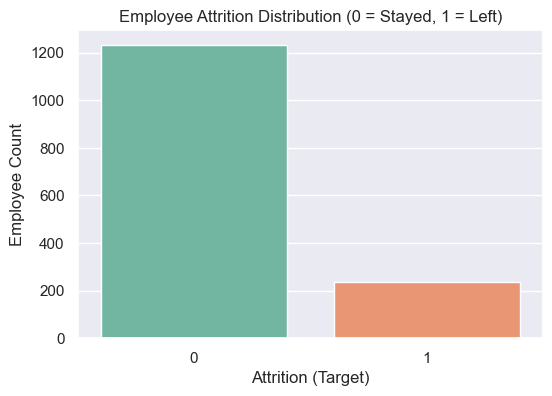

Overall Attrition Rate: 16.12%


In [6]:
# Plotting Attrition Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Employee Attrition Distribution (0 = Stayed, 1 = Left)')
plt.xlabel('Attrition (Target)')
plt.ylabel('Employee Count')
plt.show()

# Calculate the percentage of sttritions
if 'Attrition' in df.columns:
    attrition_rate = df['Attrition'].mean() * 100
    print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

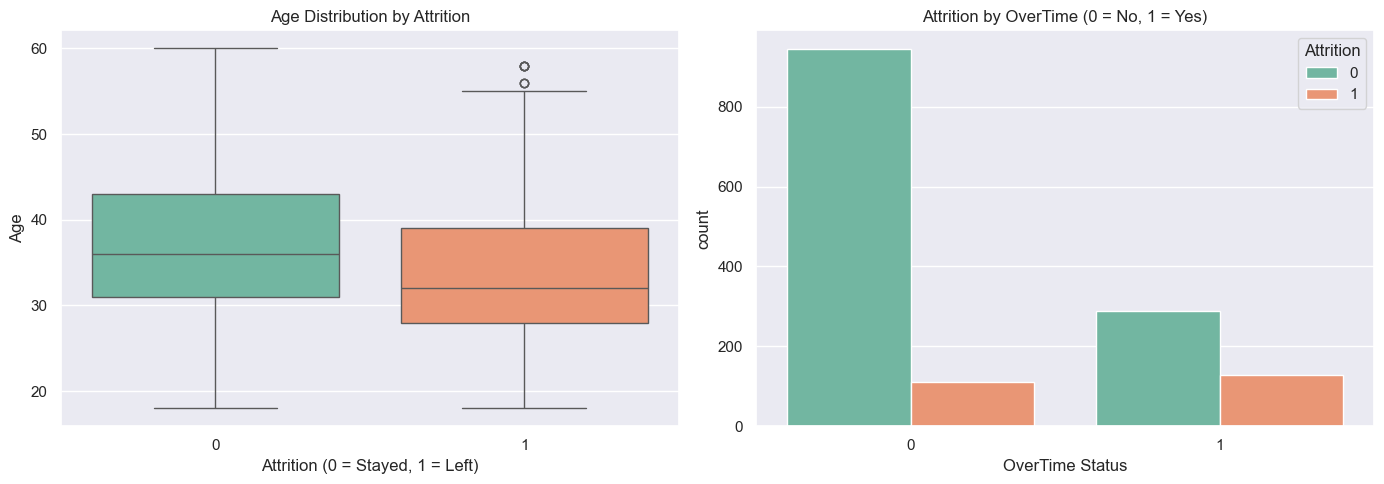

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Attrition
sns.boxplot(data=df, x='Attrition', y='Age', palette='Set2', ax=axes[0])
axes[0].set_title('Age Distribution by Attrition')
axes[0].set_xlabel('Attrition (0 = Stayed, 1 = Left)')

# OverTime vs Attrition
if 'OverTime' in df.columns:
    sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set2', ax=axes[1])
    axes[1].set_title('Attrition by OverTime (0 = No, 1 = Yes)')
    axes[1].set_xlabel('OverTime Status')

plt.tight_layout()
plt.show()

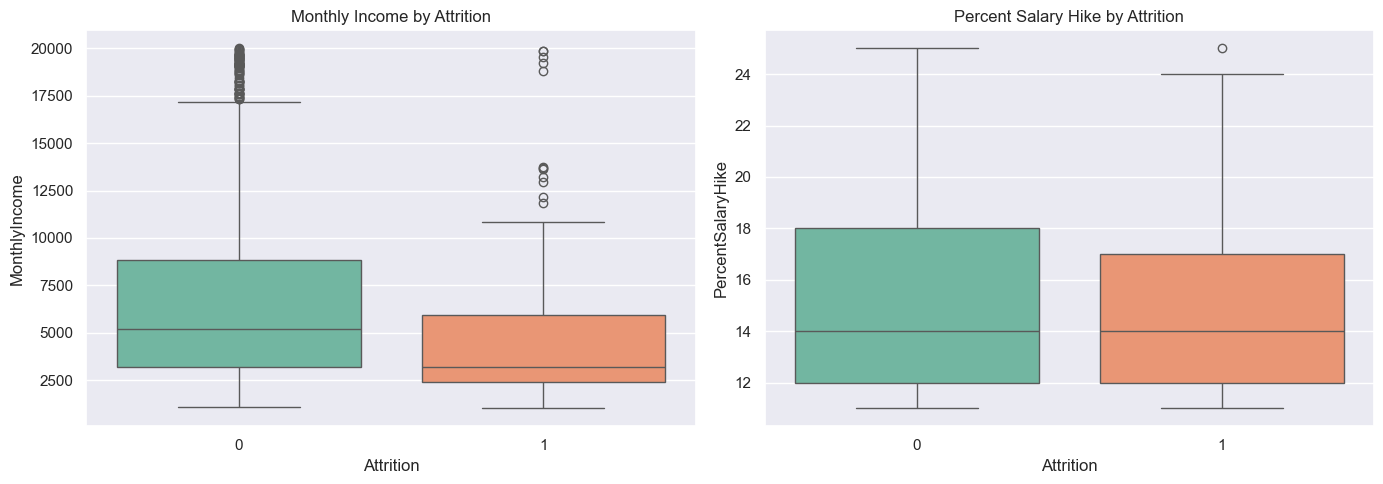

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly Income vs Attrition
if 'MonthlyIncome' in df.columns:
    sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2', ax=axes[0])
    axes[0].set_title('Monthly Income by Attrition')

# Percent Salary Hike vs Attrition
if 'PercentSalaryHike' in df.columns:
    sns.boxplot(data=df, x='Attrition', y='PercentSalaryHike', palette='Set2', ax=axes[1])
    axes[1].set_title('Percent Salary Hike by Attrition')

plt.tight_layout()
plt.show()

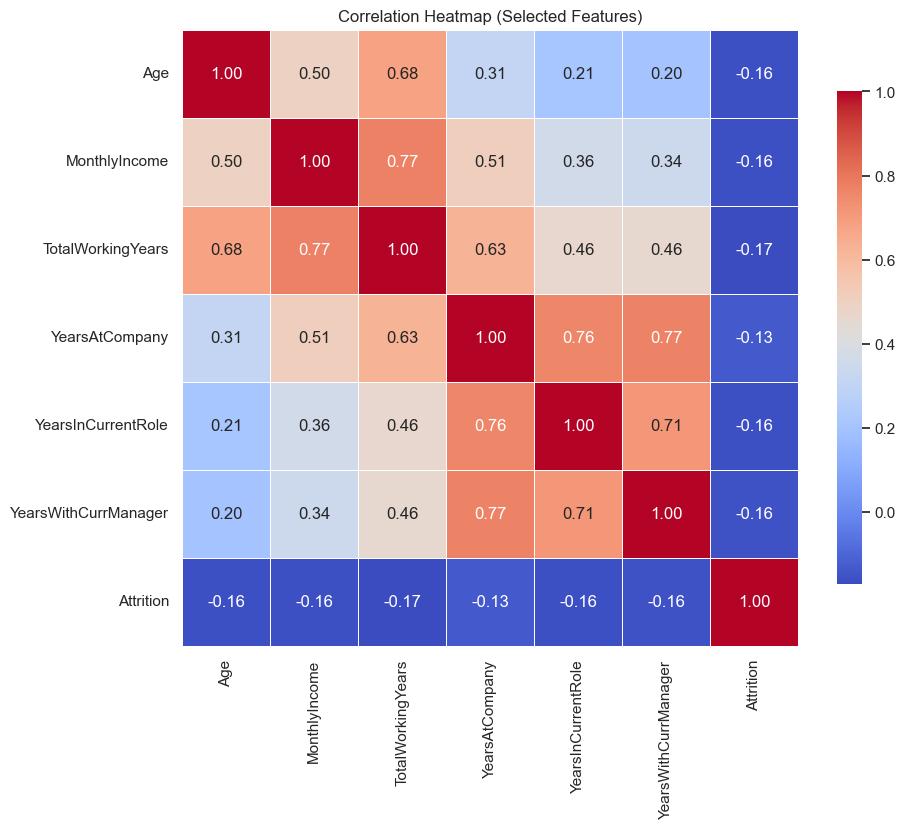

In [9]:
plt.figure(figsize=(10, 8))

# Selecting a subset of continuous numerical columns for a cleaner heatmap
num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 
            'YearsInCurrentRole', 'YearsWithCurrManager', 'Attrition']

# Ensure we only try to plot columns that actually exist in the dataframe
num_cols = [col for col in num_cols if col in df.columns]

corr_matrix = df[num_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, 
            cbar_kws={'shrink': .8}, linewidths=0.5)
plt.title('Correlation Heatmap (Selected Features)')
plt.show()

**Important insights**

1. Attrition Distribution: The Class Imbalance Problem
Technical Conclusion: Because the data is heavily skewed (84% stayed vs. 16% left), any standard machine learning model will naturally become biased toward predicting that everyone stays.
Next Step for Phase 3: We must use techniques to balance the data, such as SMOTE (Synthetic Minority Over-sampling Technique) or setting class_weight='balanced' in our algorithms. We must strictly evaluate models using F1-Score and Recall, completely ignoring standard Accuracy.
2. Age & OverTime: The Burnout Catalyst
Business Conclusion: Flight risk is concentrated in younger demographics (early 30s) who are being overworked. Overtime is not just a contributing factor; it is a primary trigger for resignation.
Actionable HR Insight: If the company wants to reduce turnover immediately, HR needs to audit the workload of junior staff and strictly regulate continuous overtime, as it is burning out the most mobile segment of the workforce.
3. Income vs. Raises: The Baseline Salary Threshold
Business Conclusion: Absolute pay matters significantly more than relative raises. An employee making a low baseline salary will still leave even if they are given a high percentage annual raise (e.g., 14%).
Actionable HR Insight: HR should focus compensation budgets on raising the baseline minimum salary (MonthlyIncome) above the $4,000–$5,000 threshold rather than offering high percentage bumps to underpaid staff, which clearly fails to retain them.
4. Correlation Matrix: Feature Redundancy
Technical Conclusion: There is high multicollinearity between tenure-based features (e.g., YearsAtCompany, YearsWithCurrManager, YearsInCurrentRole). They all feed the model the exact same underlying information.
Next Step for Phase 3: Because redundant features confuse simple linear models (like Logistic Regression), we should prioritize Tree-Based Models (like Random Forest or XGBoost) for our predictive engine, as they naturally ignore redundant variables and handle non-linear thresholds (like the minimum salary drop-off) perfectly.

**1. Relationship with Employee Attrition**

Every selected numerical feature has a slight negative correlation with attrition (ranging from -0.13 to -0.17).
Interpretation: Employees who are older, have higher monthly income, more total working experience, and longer tenure at the company or in their current role are slightly less likely to leave. While these individual linear relationships are relatively weak on their own, combined non-linear interactions across these factors are key for classification models.

**2. Strong Feature Collinearities (Inter-Feature Correlations)**

**Tenure Cluster:**

YearsAtCompany $\leftrightarrow$ YearsWithCurrManager: $0.77$

YearsAtCompany $\leftrightarrow$ YearsInCurrentRole: $0.76$

YearsInCurrentRole $\leftrightarrow$ YearsWithCurrManager: $0.71$

Insight: Employees who stay at the company longer naturally spend more time in their current roles and report to the same managers over time.

**Experience & Compensation:**

MonthlyIncome $\leftrightarrow$ TotalWorkingYears: $0.77$

TotalWorkingYears $\leftrightarrow$ Age: $0.68$

TotalWorkingYears $\leftrightarrow$ YearsAtCompany: $0.63$

Insight: As employees accumulate total years of experience, their compensation and tenure scale up proportionally.

Phase 3

In [10]:
from imblearn.over_sampling import SMOTE

# 1. Define Features (X) and Target (y)
# Drop Attrition from features; i also dropped any leftover unencoded categorical columns just in case to prevent error
X = df.drop(columns=['Attrition']).select_dtypes(exclude=['object'])
y = df['Attrition']

# 2. Train-Test Split
# stratify=y ensures the 80/20 split is maintained in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling
# Standardizing continuous variables so large numbers like Income don't overpower small numbers like Years
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Handle Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Training Target Distribution:\n{y_train.value_counts()}\n")
print(f"SMOTE Training Target Distribution (Balanced):\n{y_train_smote.value_counts()}")

Original Training Target Distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

SMOTE Training Target Distribution (Balanced):
Attrition
0    986
1    986
Name: count, dtype: int64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_smote, y_train_smote)

# Generate predictions on the unseen test set
y_pred_log = log_reg.predict(X_test_scaled)

print("--- Logistic Regression Baseline ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log))

--- Logistic Regression Baseline ---
Accuracy: 0.7687074829931972


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest
# We restrict max_depth to prevent overfitting on the synthetic SMOTE data
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# Generate predictions
y_pred_rf = rf_model.predict(X_test_scaled)

print("--- Random Forest Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

--- Random Forest Classifier ---
Accuracy: 0.8469387755102041


In [13]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train_smote, y_train_smote)

# Generate predictions
y_pred_gb = gb_model.predict(X_test_scaled)

print("--- Gradient Boosting Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

--- Gradient Boosting Classifier ---
Accuracy: 0.8605442176870748


Phase 4

--- Gradient Boosting Model Evaluation ---
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       247
           1       0.60      0.38      0.47        47

    accuracy                           0.86       294
   macro avg       0.75      0.67      0.69       294
weighted avg       0.84      0.86      0.85       294



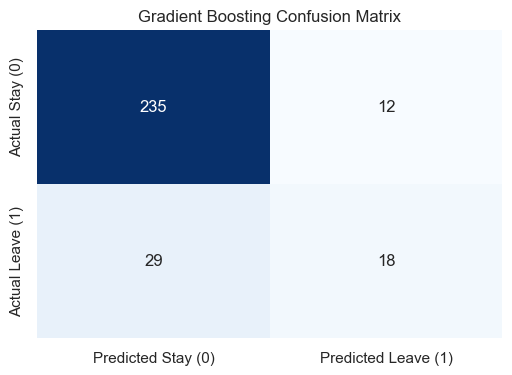

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Gradient Boosting Model Evaluation ---")
print(classification_report(y_test, y_pred_gb))

# Plotting the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Stay (0)', 'Predicted Leave (1)'],
            yticklabels=['Actual Stay (0)', 'Actual Leave (1)'])
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

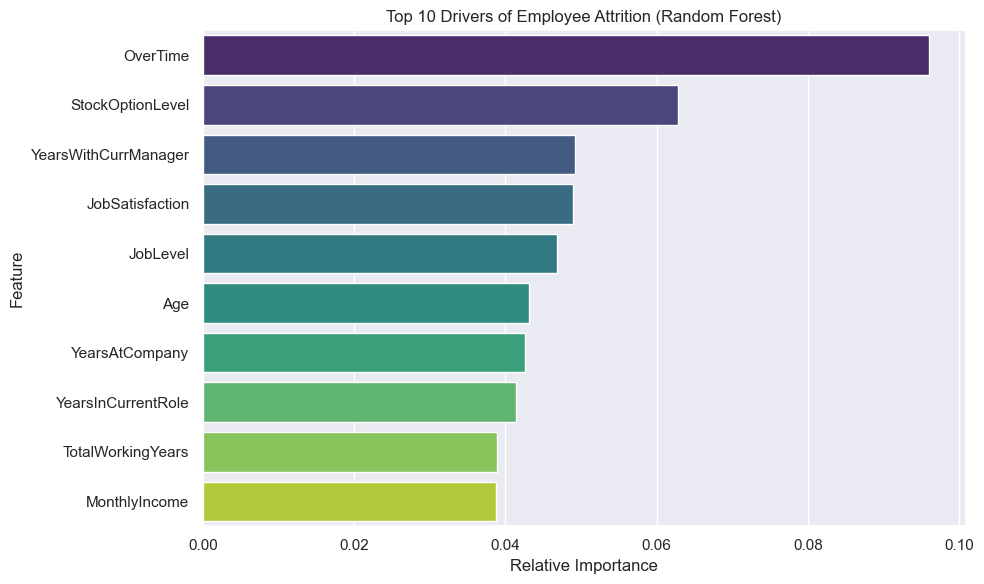

In [15]:
# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_

# Get feature names (we need to align them with the scaled data columns)
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Drivers of Employee Attrition (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Phase 5

In [16]:
import joblib

# Save the best model and the scaler to your local directory
joblib.dump(gb_model, 'attrition_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler successfully saved to disk!")

Model and Scaler successfully saved to disk!


**Adjusting the Decision Threshold**

Our default model favors precision over recall, missing too many actual leavers (False Negatives). Because a quick retention meeting costs less than replacing a departed employee, we want our model to be more aggressive. We will lower the decision threshold from 50% to 30%. If the model is even 30% sure an employee is at risk, we will flag them.

--- Gradient Boosting Evaluation (Threshold = 0.3) ---
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       247
           1       0.49      0.45      0.47        47

    accuracy                           0.84       294
   macro avg       0.69      0.68      0.69       294
weighted avg       0.83      0.84      0.83       294



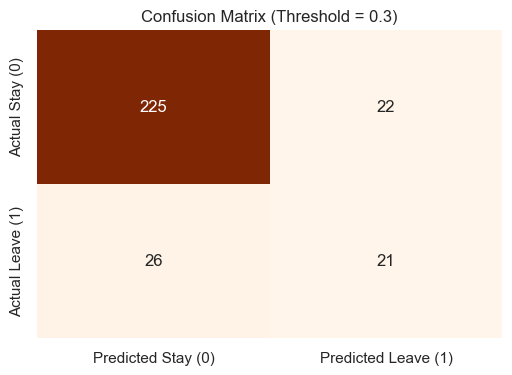

In [17]:
import numpy as np

# 1. Get the raw probability of leaving (Class 1) instead of the hard prediction
# predict_proba returns an array: [prob_stay, prob_leave]. We want all rows for column 1.
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

# 2. Define a new, more aggressive threshold
custom_threshold = 0.30

# 3. Apply the threshold to create new binary predictions
y_pred_custom = (y_prob_gb >= custom_threshold).astype(int)

# 4. Evaluate the new predictions
print(f"--- Gradient Boosting Evaluation (Threshold = {custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom))

# 5. Plot the updated Confusion Matrix
plt.figure(figsize=(6, 4))
cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted Stay (0)', 'Predicted Leave (1)'],
            yticklabels=['Actual Stay (0)', 'Actual Leave (1)'])
plt.title(f'Confusion Matrix (Threshold = {custom_threshold})')
plt.show()

**The Precision-Recall Tradeoff in Action**

What happened when we lowered the threshold from 50% to 30%:

Recall Increased (0.38 ➔ 0.45): Model is now successfully catching more of the employees who actually left. Instead of missing so many flight risks, it has cast a wider net.

Precision Dropped (0.60 ➔ 0.49): The "cost" of casting that wider net is that when the model flags someone as a flight risk, it is now only correct 49% of the time (down from 60%). We are getting more "False Positives" (flagging people who ultimately decide to stay).

Overall Accuracy Dropped (86% ➔ 84%): This is completely expected. Standard accuracy drops because we intentionally made the model "worse" at predicting the majority class (people who stay) in order to be "better" at catching the minority class (people who leave).

In [18]:
# 1. Select ONLY the features we want for our interactive Streamlit app
features_lite = ['Age', 'MonthlyIncome', 'OverTime', 'YearsAtCompany']
X_lite = df[features_lite]
y_lite = df['Attrition']

# 2. Scale and Balance the lite data
scaler_lite = StandardScaler()
X_lite_scaled = scaler_lite.fit_transform(X_lite)

smote_lite = SMOTE(random_state=42)
X_lite_smote, y_lite_smote = smote_lite.fit_resample(X_lite_scaled, y_lite)

# 3. Train the Gradient Boosting Lite Model
gb_model_lite = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model_lite.fit(X_lite_smote, y_lite_smote)

# 4. Save the Lite Model and Lite Scaler
joblib.dump(gb_model_lite, 'attrition_model_lite.pkl')
joblib.dump(scaler_lite, 'scaler_lite.pkl')

print("Dynamic Lite Model and Scaler successfully saved!")

Dynamic Lite Model and Scaler successfully saved!
